# Data Processing & Flux Analysis

This notebook processes meteorological tower observations and Eddy Covariance (EddyPro) flux outputs, adjusts UTC offsets, resamples data to 1-hour means, and merges the datasets into a unified DataFrame for surface energy balance (SEB) analysis.

### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

### Step 2: Load and Process Meteorological Tower Data

In [2]:
# File path to meteorological tower observations
filename = "/home/lacrio/cryoextremes-practicals/data/pross/met_data_1h.csv"

# Load CSV data
df_tower = pd.read_csv(filename)

# Parse datetime and adjust offset (+3 hours)
df_tower["datetime"] = pd.to_datetime(df_tower["datetime"]) + pd.Timedelta(hours=3)
df_tower = df_tower.set_index("datetime")

df_tower

,SUp,SDn,LUpCo,LDnCo,tair,rh,press,ws,wd,SHF
datetime,,,,,,,,,,
2024-12-05 03:00:00,-1.621271,-0.645508,278.950847,-308.547458,-0.765254,76.260000,1009.343220,0.0,0.705288,-8.388136
2024-12-05 04:00:00,-2.890317,-0.873267,249.340000,-305.000000,-1.202200,77.911333,1009.343383,0.0,0.667983,-7.664483
2024-12-05 05:00:00,-1.856967,-1.455250,239.385000,-302.746667,-1.549267,78.135333,1009.448533,0.0,0.632567,-6.404567
2024-12-05 06:00:00,7.741833,-2.950833,254.713333,-303.516667,-1.609117,77.461833,1009.647250,0.0,0.601150,-5.897800
2024-12-05 07:00:00,73.923833,-20.231583,252.225000,-308.655000,-1.122300,76.896667,1009.670067,0.0,0.648150,-5.436317
...,...,...,...,...,...,...,...,...,...,...
2024-12-12 23:00:00,26.785000,-4.576133,325.865000,-340.653333,4.417467,84.013333,989.174752,0.0,1.244800,2.966233
2024-12-13 00:00:00,15.160833,-2.779150,323.041667,-336.496667,3.840650,84.666667,989.347370,0.0,1.213183,0.466983
2024-12-13 01:00:00,2.367917,-0.795800,320.983333,-333.380000,3.494267,84.748333,989.682275,0.0,1.143917,-1.678683


### Step 3: Inspect EddyPro Output Columns

In [3]:
# File path to EddyPro full output file
file_path = "/home/lacrio/cryoextremes-practicals/data/EP/Pinguim_EP/eddypro_PG_OP43_full_output_2025-04-22T110846_exp.csv"

# Load CSV ignoring top metadata header rows and treating -9999 as missing values
df = pd.read_csv(file_path, sep=",", skiprows=[0, 2], na_values=-9999)

# Inspect column names
print(df.columns)

Index(['filename', 'date', 'time', 'DOY', 'daytime', 'file_records',
       'used_records', 'Tau', 'qc_Tau', 'H',
       ...
       'u_var', 'v_var', 'w_var', 'ts_var', 'co2_var', 'h2o_var', 'w/ts_cov',
       'w/co2_cov', 'w/h2o_cov', 'ts_mean'],
      dtype='object', length=111)


### Step 4: Filter and Resample EddyPro Data

In [4]:
# Select target micrometeorological variables
df_sel = df[["date", "time", "H", "LE", "air_temperature", "RH", "wind_speed"]].copy()

# Construct datetime index and apply time zone shift (+3 hours)
df_sel["datetime"] = pd.to_datetime(df_sel["date"] + " " + df_sel["time"]) + pd.Timedelta(hours=3)
df_sel = df_sel.set_index("datetime").drop(columns=["date", "time"])

# Restrict time range and resample to 1-hour averages
df_sel = df_sel.loc["2024-12-06":"2024-12-13"].resample("1h").mean()

df_sel

,H,LE,air_temperature,RH,wind_speed
datetime,,,,,
2024-12-06 00:00:00,-1.901235,11.726755,271.9120,31.62395,5.561705
2024-12-06 01:00:00,0.631121,7.187795,271.7135,32.08870,4.203325
2024-12-06 02:00:00,-2.266559,7.318640,271.7515,31.39660,3.549855
2024-12-06 03:00:00,-2.780205,11.428450,271.8340,29.41310,5.124625
2024-12-06 04:00:00,0.286868,2.755210,271.8150,33.93900,4.898640
...,...,...,...,...,...
2024-12-13 19:00:00,12.207600,51.200550,277.0655,65.14275,5.295150
2024-12-13 20:00:00,-2.571735,44.480350,276.9440,61.27955,5.929220
2024-12-13 21:00:00,-2.462405,22.956950,276.9780,55.61320,6.534520


### Step 5: Merge Datasets

In [5]:
# Select desired variables from each dataset
cols_tower = ["SUp", "SDn", "LUpCo", "LDnCo", "SHF"]
cols_eddy = ["H", "LE"]

# Merge datasets on datetime index
df_merged = pd.merge(df_tower[cols_tower], df_sel[cols_eddy], on="datetime", how="inner")

df_merged

,SUp,SDn,LUpCo,LDnCo,SHF,H,LE
datetime,,,,,,,
2024-12-06 00:00:00,22.027583,-6.099033,221.720000,-304.818333,-6.790317,-1.901235,11.726755
2024-12-06 01:00:00,1.502833,-2.493850,217.453333,-301.495000,-8.338000,0.631121,7.187795
2024-12-06 02:00:00,-3.403450,-1.519867,212.940000,-300.505000,-8.456500,-2.266559,7.318640
2024-12-06 03:00:00,-3.904550,-1.224900,214.573333,-300.468333,-8.127267,-2.780205,11.428450
2024-12-06 04:00:00,-3.590267,-1.192567,215.496667,-300.398333,-7.540617,0.286868,2.755210
...,...,...,...,...,...,...,...
2024-12-12 23:00:00,26.785000,-4.576133,325.865000,-340.653333,2.966233,-0.417020,1.167915
2024-12-13 00:00:00,15.160833,-2.779150,323.041667,-336.496667,0.466983,1.013071,2.805850
2024-12-13 01:00:00,2.367917,-0.795800,320.983333,-333.380000,-1.678683,7.092960,5.850520


<Axes: xlabel='datetime'>

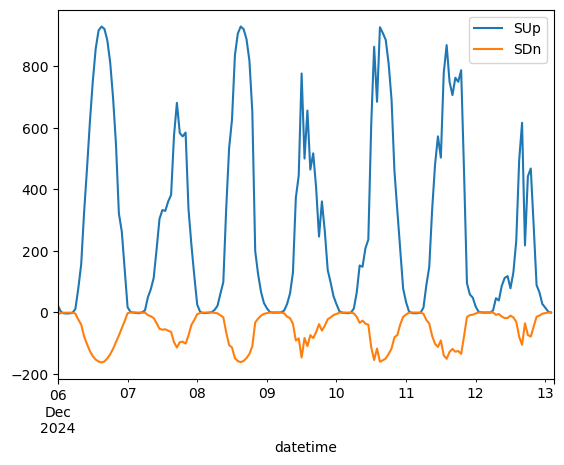

In [6]:
df_merged[['SUp', 'SDn']].plot()

In [7]:
# Set negative values in SUp and SDn to 0
# Si SUp es menor que 0, asigna 0 a ambas columnas ('SUp' y 'SDn')
df_merged.loc[df_merged['SUp'] < 0, ['SUp', 'SDn']] = 0

<Axes: xlabel='datetime'>

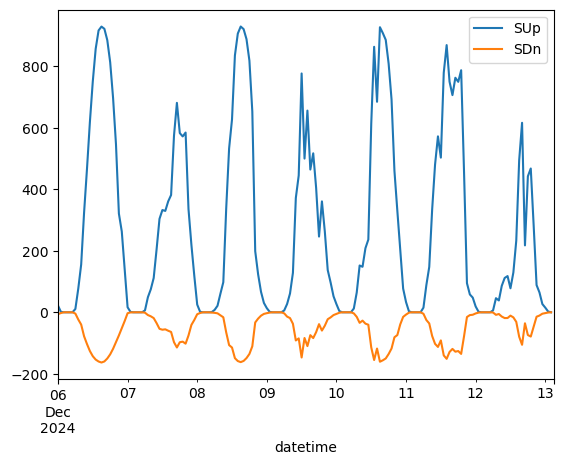

In [8]:
df_merged[['SUp', 'SDn']].plot()

In [9]:
df_merged

,SUp,SDn,LUpCo,LDnCo,SHF,H,LE
datetime,,,,,,,
2024-12-06 00:00:00,22.027583,-6.099033,221.720000,-304.818333,-6.790317,-1.901235,11.726755
2024-12-06 01:00:00,1.502833,-2.493850,217.453333,-301.495000,-8.338000,0.631121,7.187795
2024-12-06 02:00:00,0.000000,0.000000,212.940000,-300.505000,-8.456500,-2.266559,7.318640
2024-12-06 03:00:00,0.000000,0.000000,214.573333,-300.468333,-8.127267,-2.780205,11.428450
2024-12-06 04:00:00,0.000000,0.000000,215.496667,-300.398333,-7.540617,0.286868,2.755210
...,...,...,...,...,...,...,...
2024-12-12 23:00:00,26.785000,-4.576133,325.865000,-340.653333,2.966233,-0.417020,1.167915
2024-12-13 00:00:00,15.160833,-2.779150,323.041667,-336.496667,0.466983,1.013071,2.805850
2024-12-13 01:00:00,2.367917,-0.795800,320.983333,-333.380000,-1.678683,7.092960,5.850520


### Step 6: 3-Panel Visualization (Radiation, Turbulent & Soil Fluxes, Surface Energy Balance)

#### Step 6.1:  Surface Energy Balance

In [10]:
# 1. Calculate Net Radiation and Surface Energy Balance terms
df_merged["Rn"] = (df_merged["SDn"] + df_merged["SUp"]) + (df_merged["LDnCo"] + df_merged["LUpCo"])
df_merged["SEB_Consumed"] = df_merged["H"] + df_merged["LE"] + df_merged["SHF"]
df_merged["SEB_Residual"] = df_merged["Rn"] - df_merged["SEB_Consumed"]
df_merged

,SUp,SDn,LUpCo,LDnCo,SHF,H,LE,Rn,SEB_Consumed,SEB_Residual
datetime,,,,,,,,,,
2024-12-06 00:00:00,22.027583,-6.099033,221.720000,-304.818333,-6.790317,-1.901235,11.726755,-67.169783,3.035203,-70.204987
2024-12-06 01:00:00,1.502833,-2.493850,217.453333,-301.495000,-8.338000,0.631121,7.187795,-85.032683,-0.519084,-84.513600
2024-12-06 02:00:00,0.000000,0.000000,212.940000,-300.505000,-8.456500,-2.266559,7.318640,-87.565000,-3.404419,-84.160581
2024-12-06 03:00:00,0.000000,0.000000,214.573333,-300.468333,-8.127267,-2.780205,11.428450,-85.895000,0.520978,-86.415978
2024-12-06 04:00:00,0.000000,0.000000,215.496667,-300.398333,-7.540617,0.286868,2.755210,-84.901667,-4.498539,-80.403128
...,...,...,...,...,...,...,...,...,...,...
2024-12-12 23:00:00,26.785000,-4.576133,325.865000,-340.653333,2.966233,-0.417020,1.167915,7.420533,3.717128,3.703405
2024-12-13 00:00:00,15.160833,-2.779150,323.041667,-336.496667,0.466983,1.013071,2.805850,-1.073317,4.285904,-5.359221
2024-12-13 01:00:00,2.367917,-0.795800,320.983333,-333.380000,-1.678683,7.092960,5.850520,-10.824550,11.264797,-22.089347


#### Step 6.2: 3-Panel Visualization (Radiation, Turbulent & Soil Fluxes, Surface Energy Balance)

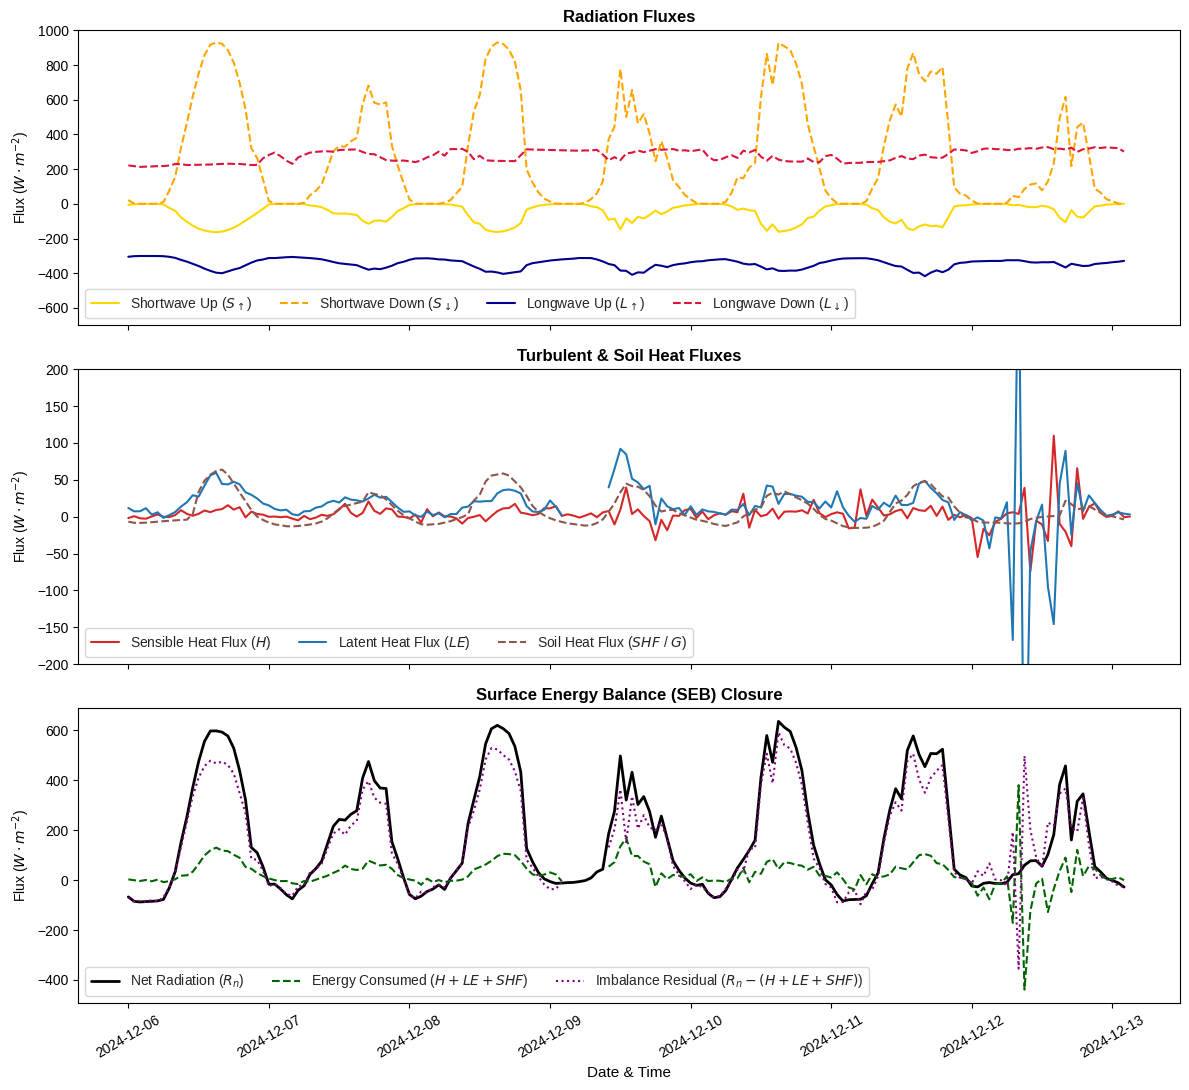

In [11]:
# 2. Figure Setup with 3 Subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)

# --- Subplot 1: Radiation Fluxes ---
# Intercambiamos los labels entre SDn y SUp, y entre LDnCo y LUpCo para ajustar a los datos reales
ax1.plot(
    df_merged.index,
    df_merged["SDn"],
    label="Shortwave Up ($S_{\\uparrow}$)",
    color="gold",
    linewidth=1.5,
)
ax1.plot(
    df_merged.index,
    df_merged["SUp"],
    label="Shortwave Down ($S_{\\downarrow}$)",
    color="orange",
    linestyle="--",
    linewidth=1.5,
)
ax1.plot(
    df_merged.index,
    df_merged["LDnCo"],
    label="Longwave Up ($L_{\\uparrow}$)",
    color="darkblue",
    linewidth=1.5,
)
ax1.plot(
    df_merged.index,
    df_merged["LUpCo"],
    label="Longwave Down ($L_{\\downarrow}$)",
    color="crimson",
    linestyle="--",
    linewidth=1.5,
)
ax1.set_ylabel("Flux ($W\\cdot m^{-2}$)", fontsize=10)
ax1.set_title("Radiation Fluxes", fontsize=12, fontweight="bold")
ax1.set_ylim(-700, 1000)
ax1.legend(loc="lower left", frameon=True, ncol=4)

# --- Subplot 2: Turbulent & Soil Heat Fluxes ---
ax2.plot(
    df_merged.index,
    df_merged["H"],
    label="Sensible Heat Flux ($H$)",
    color="tab:red",
    linewidth=1.5,
)
ax2.plot(
    df_merged.index,
    df_merged["LE"],
    label="Latent Heat Flux ($LE$)",
    color="tab:blue",
    linewidth=1.5,
)
ax2.plot(
    df_merged.index,
    df_merged["SHF"],
    label="Soil Heat Flux ($SHF$ / $G$)",
    color="tab:brown",
    linestyle="--",
    linewidth=1.5,
)
ax2.set_ylabel("Flux ($W\\cdot m^{-2}$)", fontsize=10)
ax2.set_ylim(-200, 200)
ax2.set_title("Turbulent & Soil Heat Fluxes", fontsize=12, fontweight="bold")
ax2.legend(loc="lower left", frameon=True, ncol=3)

# --- Subplot 3: Surface Energy Balance (SEB) ---
ax3.plot(
    df_merged.index,
    df_merged["Rn"],
    label="Net Radiation ($R_n$)",
    color="black",
    linewidth=2,
)
ax3.plot(
    df_merged.index,
    df_merged["SEB_Consumed"],
    label="Energy Consumed ($H + LE + SHF$)",
    color="darkgreen",
    linestyle="--",
    linewidth=1.5,
)
ax3.plot(
    df_merged.index,
    df_merged["SEB_Residual"],
    label="Imbalance Residual ($R_n - (H+LE+SHF)$)",
    color="purple",
    linestyle=":",
    linewidth=1.5,
)
ax3.set_ylabel("Flux ($W\\cdot m^{-2}$)", fontsize=10)
ax3.set_xlabel("Date & Time", fontsize=11)
ax3.set_title(
    "Surface Energy Balance (SEB) Closure", fontsize=12, fontweight="bold"
)
ax3.legend(loc="lower left", frameon=True, ncol=3)

plt.xticks(rotation=30)
plt.tight_layout()

# Save figure
output_dir = "fig"
save_path = os.path.join(output_dir, f"fig_seb.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

In [12]:
# Limpieza de picos de inestabilidad en flujos turbulentos
cols_turbulentos = ['H', 'LE']

# 1. Aplicar umbrales
df_merged[cols_turbulentos] = df_merged[cols_turbulentos].mask(
    (df_merged[cols_turbulentos] < -150) | (df_merged[cols_turbulentos] > 150)
)

# 2. Interpolar huecos
df_merged[cols_turbulentos] = df_merged[cols_turbulentos].interpolate(
    method='time'
)

In [13]:
df_merged

,SUp,SDn,LUpCo,LDnCo,SHF,H,LE,Rn,SEB_Consumed,SEB_Residual
datetime,,,,,,,,,,
2024-12-06 00:00:00,22.027583,-6.099033,221.720000,-304.818333,-6.790317,-1.901235,11.726755,-67.169783,3.035203,-70.204987
2024-12-06 01:00:00,1.502833,-2.493850,217.453333,-301.495000,-8.338000,0.631121,7.187795,-85.032683,-0.519084,-84.513600
2024-12-06 02:00:00,0.000000,0.000000,212.940000,-300.505000,-8.456500,-2.266559,7.318640,-87.565000,-3.404419,-84.160581
2024-12-06 03:00:00,0.000000,0.000000,214.573333,-300.468333,-8.127267,-2.780205,11.428450,-85.895000,0.520978,-86.415978
2024-12-06 04:00:00,0.000000,0.000000,215.496667,-300.398333,-7.540617,0.286868,2.755210,-84.901667,-4.498539,-80.403128
...,...,...,...,...,...,...,...,...,...,...
2024-12-12 23:00:00,26.785000,-4.576133,325.865000,-340.653333,2.966233,-0.417020,1.167915,7.420533,3.717128,3.703405
2024-12-13 00:00:00,15.160833,-2.779150,323.041667,-336.496667,0.466983,1.013071,2.805850,-1.073317,4.285904,-5.359221
2024-12-13 01:00:00,2.367917,-0.795800,320.983333,-333.380000,-1.678683,7.092960,5.850520,-10.824550,11.264797,-22.089347


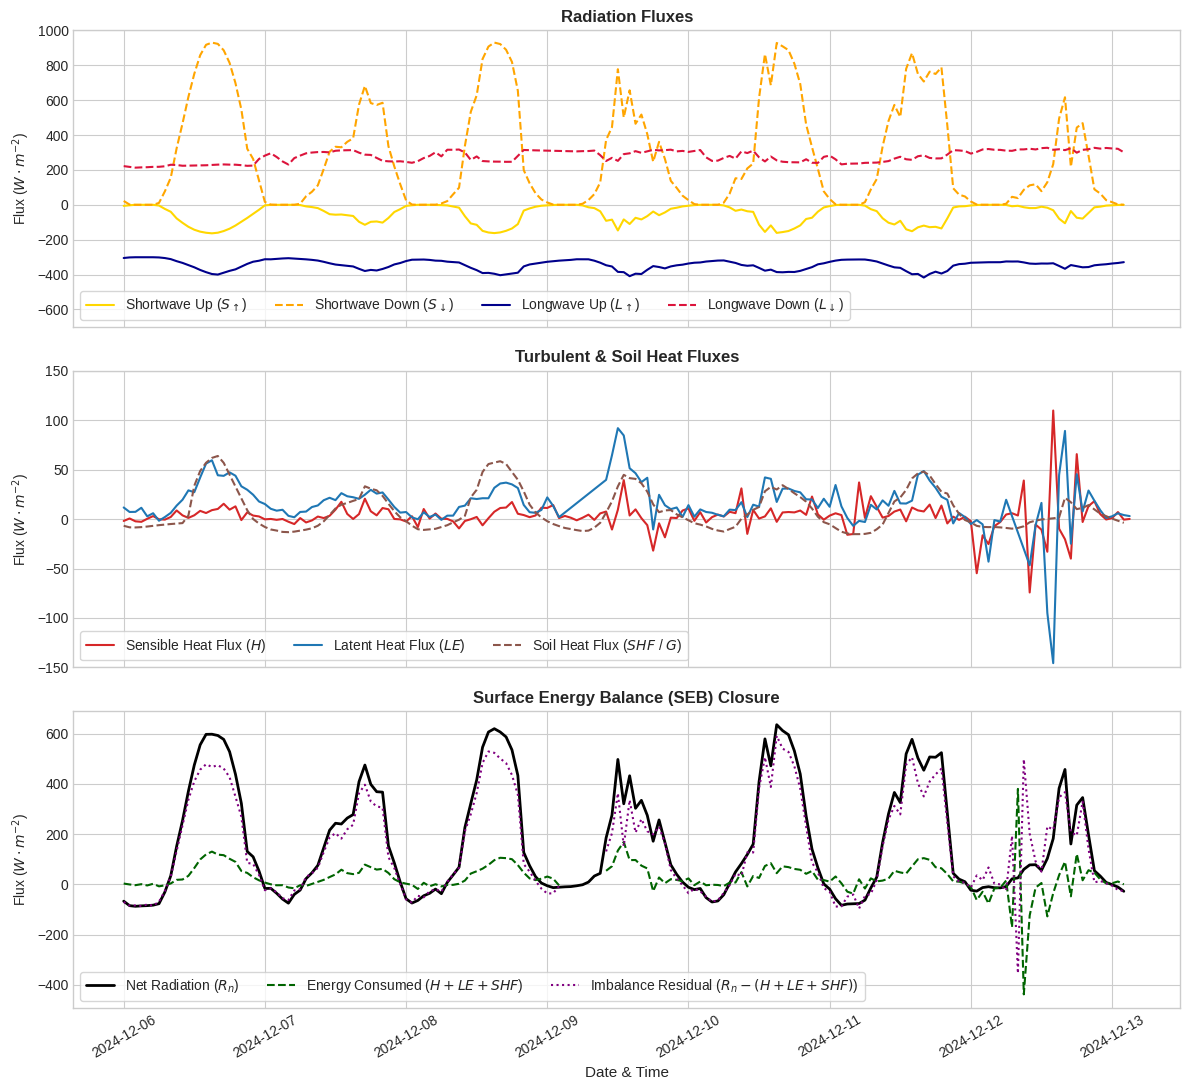

In [14]:
# 2. Figure Setup with 3 Subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)

# --- Subplot 1: Radiation Fluxes ---
# Intercambiamos los labels entre SDn y SUp, y entre LDnCo y LUpCo para ajustar a los datos reales
ax1.plot(
    df_merged.index,
    df_merged["SDn"],
    label="Shortwave Up ($S_{\\uparrow}$)",
    color="gold",
    linewidth=1.5,
)
ax1.plot(
    df_merged.index,
    df_merged["SUp"],
    label="Shortwave Down ($S_{\\downarrow}$)",
    color="orange",
    linestyle="--",
    linewidth=1.5,
)
ax1.plot(
    df_merged.index,
    df_merged["LDnCo"],
    label="Longwave Up ($L_{\\uparrow}$)",
    color="darkblue",
    linewidth=1.5,
)
ax1.plot(
    df_merged.index,
    df_merged["LUpCo"],
    label="Longwave Down ($L_{\\downarrow}$)",
    color="crimson",
    linestyle="--",
    linewidth=1.5,
)
ax1.set_ylabel("Flux ($W\\cdot m^{-2}$)", fontsize=10)
ax1.set_title("Radiation Fluxes", fontsize=12, fontweight="bold")
ax1.set_ylim(-700, 1000)
ax1.legend(loc="lower left", frameon=True, ncol=4)

# --- Subplot 2: Turbulent & Soil Heat Fluxes ---
ax2.plot(
    df_merged.index,
    df_merged["H"],
    label="Sensible Heat Flux ($H$)",
    color="tab:red",
    linewidth=1.5,
)
ax2.plot(
    df_merged.index,
    df_merged["LE"],
    label="Latent Heat Flux ($LE$)",
    color="tab:blue",
    linewidth=1.5,
)
ax2.plot(
    df_merged.index,
    df_merged["SHF"],
    label="Soil Heat Flux ($SHF$ / $G$)",
    color="tab:brown",
    linestyle="--",
    linewidth=1.5,
)
ax2.set_ylabel("Flux ($W\\cdot m^{-2}$)", fontsize=10)
ax2.set_ylim(-150, 150)
ax2.set_title("Turbulent & Soil Heat Fluxes", fontsize=12, fontweight="bold")
ax2.legend(loc="lower left", frameon=True, ncol=3)

# --- Subplot 3: Surface Energy Balance (SEB) ---
ax3.plot(
    df_merged.index,
    df_merged["Rn"],
    label="Net Radiation ($R_n$)",
    color="black",
    linewidth=2,
)
ax3.plot(
    df_merged.index,
    df_merged["SEB_Consumed"],
    label="Energy Consumed ($H + LE + SHF$)",
    color="darkgreen",
    linestyle="--",
    linewidth=1.5,
)
ax3.plot(
    df_merged.index,
    df_merged["SEB_Residual"],
    label="Imbalance Residual ($R_n - (H+LE+SHF)$)",
    color="purple",
    linestyle=":",
    linewidth=1.5,
)
ax3.set_ylabel("Flux ($W\\cdot m^{-2}$)", fontsize=10)
ax3.set_xlabel("Date & Time", fontsize=11)
ax3.set_title(
    "Surface Energy Balance (SEB) Closure", fontsize=12, fontweight="bold"
)
ax3.legend(loc="lower left", frameon=True, ncol=3)

plt.xticks(rotation=30)
plt.tight_layout()

# Save figure
output_dir = "fig"
save_path = os.path.join(output_dir, f"fig_seb_corr.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

In [15]:
# Si datetime es el índice en los DataFrames:
df_merged = pd.concat(
    [df_merged, df_tower[["tair", "rh", "press"]], df_sel[["wind_speed"]]],
    axis=1,
    join="inner",
)

# Si datetime es una columna normal, ajústalo primero como índice:
# df_merged = pd.concat([
#     df_merged.set_index('datetime'),
#     df_tower[['tair', 'rh', 'press']], # asumiendo que datetime ya es el índice
#     df_sel[['wind_speed']]
# ], axis=1, join='inner').reset_index()

df_merged.to_csv("data/pross/data_tower.csv", sep="\t")